# Support Vector Machine (SVM)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import time
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print("SVM model ready for training")

SVM model ready for training


back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Hyperparameter Tuning with GridSearchCV

We use `GridSearchCV` to systematically explore the best hyperparameters and optimize for F1-score.

Note: We use a smaller subset of hyperparameters to balance computational efficiency with model quality.
`LinearSVC` with kernel='linear' is significantly faster than `SVC`, but we also test `SVC` with linear kernel for comparison.

In [8]:
# Define the hyperparameter search space
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],            # Regularization strength
    'loss': ['squared_hinge', 'hinge'],             # Loss function for LinearSVC
    'penalty': ['l1', 'l2'],                        # Regularization type
    'max_iter': [2000, 3000],                       # Convergence iterations
}
# Base estimator — LinearSVC (efficient for sparse TF-IDF data)
base_svm = LinearSVC(dual='auto', random_state=42, verbose=0)
print("Starting GridSearchCV for LinearSVC...")
search_start = time.time()
grid_search = GridSearchCV(
    estimator=base_svm,
    param_grid=param_grid,
    scoring='f1',                  # Optimize for F1 (balanced metric for binary sentiment)
    cv=3,                          # 3-fold cross-validation
    n_jobs=10,
    verbose=2,
    refit=True                     # Refit best model on the full training set
)
grid_search.fit(X_train_tfidf, y_train)
search_time = time.time() - search_start
print(f"\nGridSearchCV completed in {search_time:.4f} seconds")

Starting GridSearchCV for LinearSVC...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

GridSearchCV completed in 85.3992 seconds


In [9]:
# Inspect the best hyperparameters found
print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {grid_search.best_score_:.4f}")

Best Parameters:
  C: 1.0
  loss: hinge
  max_iter: 2000
  penalty: l2

Best CV F1-Score: 0.8875


In [10]:
# CV results summary — top 10 combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
top_results = (
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 hyperparameter combinations (by F1):")
print(top_results.to_string(index=False))

Top 10 hyperparameter combinations (by F1):
                                                                 params  mean_test_score  std_test_score  rank_test_score
         {'C': 1.0, 'loss': 'hinge', 'max_iter': 2000, 'penalty': 'l2'}         0.887476        0.000835                1
         {'C': 1.0, 'loss': 'hinge', 'max_iter': 3000, 'penalty': 'l2'}         0.887476        0.000835                1
 {'C': 1.0, 'loss': 'squared_hinge', 'max_iter': 3000, 'penalty': 'l2'}         0.886403        0.000776                3
 {'C': 1.0, 'loss': 'squared_hinge', 'max_iter': 2000, 'penalty': 'l2'}         0.886403        0.000776                3
 {'C': 0.1, 'loss': 'squared_hinge', 'max_iter': 3000, 'penalty': 'l2'}         0.884512        0.001699                5
 {'C': 0.1, 'loss': 'squared_hinge', 'max_iter': 2000, 'penalty': 'l2'}         0.884512        0.001699                5
 {'C': 1.0, 'loss': 'squared_hinge', 'max_iter': 2000, 'penalty': 'l1'}         0.881586        0.0012

## SVM Model Training (LinearSVC for efficiency)

In [12]:
# Retrieve the best estimator (already refit on the full training set)
svm_classifier = grid_search.best_estimator_

print(f"Final SVM Model trained with best hyperparameters:")
print(f"  Training set size: {X_train_tfidf.shape}")
print(f"  F1-Score (CV): {grid_search.best_score_:.4f}")

Final SVM Model trained with best hyperparameters:
  Training set size: (79972, 100000)
  F1-Score (CV): 0.8875


In [ ]:
# # # Train SVC (enormous amount of time and RAM)
# print("Training LinearSVC Classifier...")
# start_time = time.time()
# svm_classifier = SVC(
#     kernel='linear',
#     # degree=3,  # Try 2, 3, 4, 5...
#     C=1.0,  # Regularization parameter
#     gamma='scale',
#     # coef0=1.0,
#     probability=True,
#     max_iter=2000,  # Maximum iterations
#     random_state=42,
#     verbose=0,
# )
# svm_classifier.fit(X_train_tfidf, y_train)
# training_time = time.time() - start_time
# print(f"Training completed in {training_time:.4f} seconds")

## Model Evaluation

In [ ]:
# Make predictions
y_pred = svm_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("SVM (LinearSVC) CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {search_time:.4f} seconds")

SVM (LinearSVC) CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8891
Precision: 0.8883
Recall:    0.8892
F1-Score:  0.8888


## Classification Report

In [16]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      9966
    Positive       0.89      0.89      0.89     10034

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



## Confusion Matrix Visualization

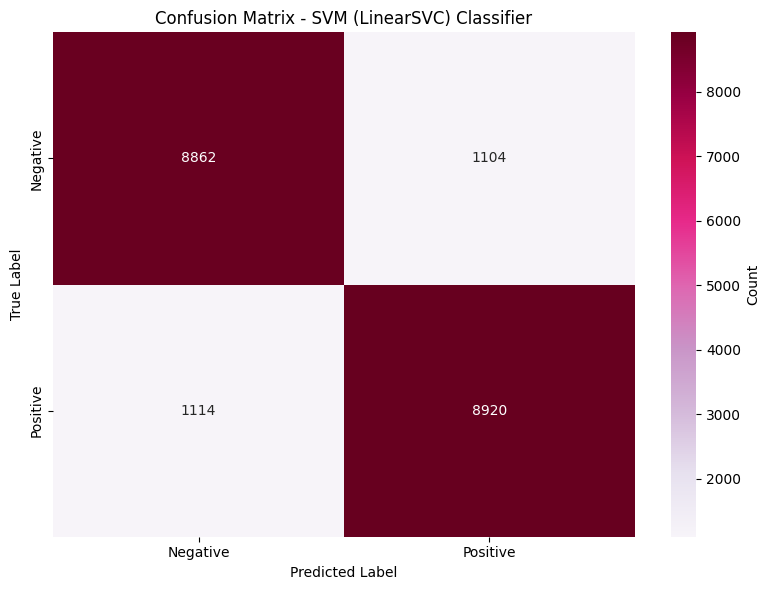

Confusion Matrix:
[[8862 1104]
 [1114 8920]]

True Negatives: 8862
False Positives: 1104
False Negatives: 1114
True Positives: 8920


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - SVM (LinearSVC) Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('docs/02_results/svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Coefficients (SVM Weights)

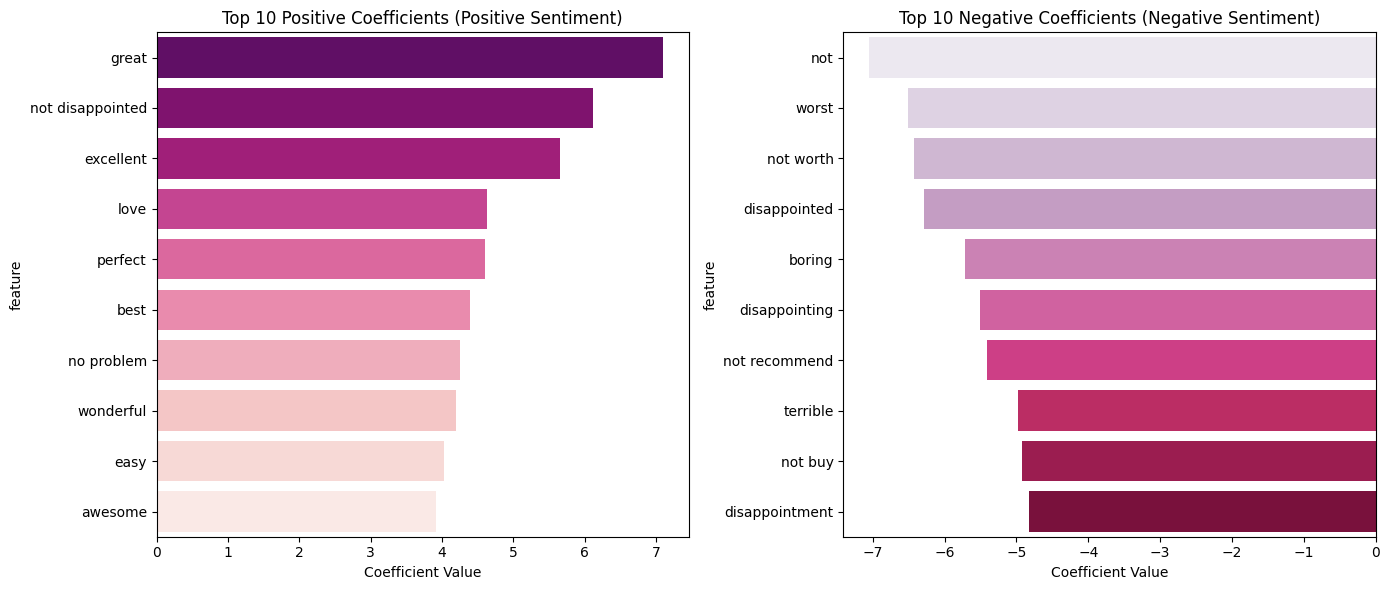


Top 10 Positive Coefficients (Positive Sentiment Indicators):
         feature  coefficient
           great     7.105326
not disappointed     6.112206
       excellent     5.655528
            love     4.637903
         perfect     4.602986
            best     4.389998
      no problem     4.249763
       wonderful     4.201641
            easy     4.034639
         awesome     3.913594

Top 10 Negative Coefficients (Negative Sentiment Indicators):
       feature  coefficient
           not    -7.055084
         worst    -6.503667
     not worth    -6.432831
  disappointed    -6.281118
        boring    -5.715144
 disappointing    -5.511028
 not recommend    -5.407764
      terrible    -4.978311
       not buy    -4.919727
disappointment    -4.829293


In [ ]:
# Get feature coefficients (weights)
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
# coefficients = svm_classifier.coef_[0] # Old code
# coefficients = svm_classifier.coef_.toarray().flatten() # Old code
# Handles both sparse and dense matrices
coef_matrix = svm_classifier.coef_
if hasattr(coef_matrix, 'toarray'):  # Sparse matrix
    coefficients = coef_matrix.toarray().flatten()
else:  # Dense array
    coefficients = coef_matrix.flatten()
# Create DataFrame for better visualization
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})
# Get top positive and negative features
top_positive = coef_df.nlargest(10, 'coefficient')
top_negative = coef_df.nsmallest(10, 'coefficient')
# Plot top coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_positive, x='coefficient', y='feature', palette='RdPu_r', ax=axes[0])
axes[0].set_title('Top 10 Positive Coefficients (Positive Sentiment)')
axes[0].set_xlabel('Coefficient Value')
sns.barplot(data=top_negative, x='coefficient', y='feature', palette='PuRd', ax=axes[1])
axes[1].set_title('Top 10 Negative Coefficients (Negative Sentiment)')
axes[1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('docs/02_results/svm_feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 10 Positive Coefficients (Positive Sentiment Indicators):")
print(top_positive.to_string(index=False))
print("\nTop 10 Negative Coefficients (Negative Sentiment Indicators):")
print(top_negative.to_string(index=False))

## Decision Boundary Analysis

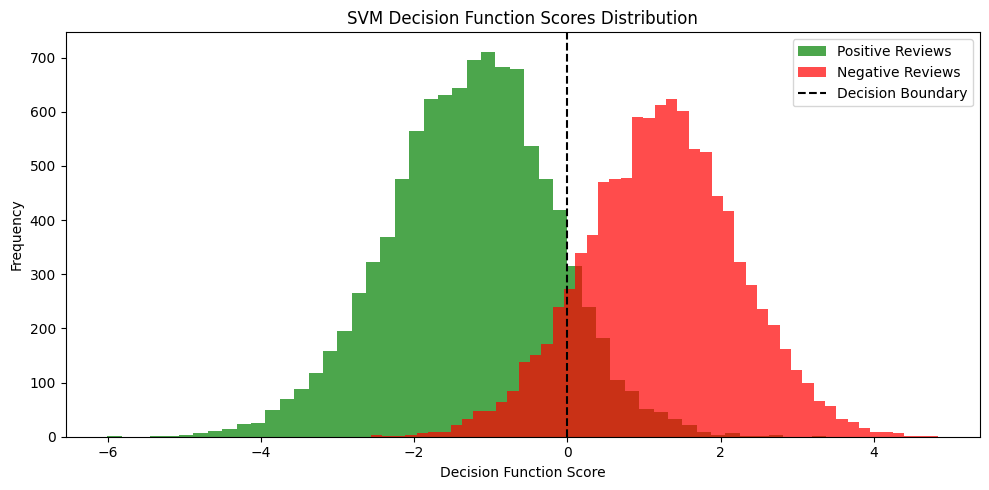


Decision Function Statistics:
Mean score for positive reviews: -1.2665
Mean score for negative reviews: 1.2209
Min decision score: -6.0056
Max decision score: 4.8417


In [ ]:
# Get decision function scores
decision_scores = svm_classifier.decision_function(X_test_tfidf)
# Plot distribution of decision scores
plt.figure(figsize=(10, 5))
plt.hist(decision_scores[y_test == 1], bins=50, alpha=0.7, label='Positive Reviews', color='green')
plt.hist(decision_scores[y_test == 2], bins=50, alpha=0.7, label='Negative Reviews', color='red')
plt.axvline(0, color='black', linestyle='--', label='Decision Boundary')
plt.xlabel('Decision Function Score')
plt.ylabel('Frequency')
plt.title('SVM Decision Function Scores Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('docs/02_results/svm_decision_scores.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nDecision Function Statistics:")
print(f"Mean score for positive reviews: {decision_scores[y_test == 1].mean():.4f}")
print(f"Mean score for negative reviews: {decision_scores[y_test == 2].mean():.4f}")
print(f"Min decision score: {decision_scores.min():.4f}")
print(f"Max decision score: {decision_scores.max():.4f}")

## Model Summary

In [ ]:
print("SVM (LinearSVC) MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Kernel: Linear (implicit in LinearSVC)")
print(f"  - C (Regularization): {svm_classifier.C}")
print(f"  - Loss Function: hinge")
print(f"  - Penalty: L2")
print(f"  - Max Iterations: {svm_classifier.max_iter}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {search_time:.4f} seconds")
print(f"\nModel Characteristics:")
print(f"  - Type: LinearSVC (Support Vector Classification)")
print(f"  - Complexity: O(n × d) where n=samples, d=features")
print(f"  - Number of Coefficients: {len(coefficients)}")
print(f"  - Best for: High-dimensional sparse data (like TF-IDF)")
print(f"  - Margin-based Classifier: Maximizes decision boundary margin")

SVM (LinearSVC) MODEL SUMMARY

Model Parameters:
  - Kernel: Linear (implicit in LinearSVC)
  - C (Regularization): 1.0
  - Loss Function: hinge
  - Penalty: L2
  - Max Iterations: 2000

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8891
  - Precision: 0.8883
  - Recall:    0.8892
  - F1-Score:  0.8888

Model Characteristics:
  - Type: LinearSVC (Support Vector Classification)
  - Complexity: O(n × d) where n=samples, d=features
  - Number of Coefficients: 100000
  - Best for: High-dimensional sparse data (like TF-IDF)
  - Margin-based Classifier: Maximizes decision boundary margin


## Saving the Model and Pipeline

In [22]:
save(model_base='data/models', model=svm_classifier, model_name='07_support_vector_machine_classifier.joblib')

Saved model 07_support_vector_machine_classifier.joblib to data\models\07_support_vector_machine_classifier.joblib


{'model': WindowsPath('data/models/07_support_vector_machine_classifier.joblib')}